# Understanding Embeddings — A Hands-On Guide

**Goal of this notebook:** build an intuition for what a *text embedding* is, why it's useful, and how to work with one — using OpenAI's embedding models.

### What is an embedding?

An **embedding** is a list of numbers (a *vector*) that represents the *meaning* of a piece of text.

The key idea: **text that means similar things gets similar vectors.** A computer can't compare the *meaning* of two sentences directly — but it *can* compare two lists of numbers. Embeddings are the bridge.

```
   "cat"    ->  [ 0.02, -0.11,  0.34, ... ]   
   "kitten" ->  [ 0.03, -0.09,  0.31, ... ]   <- close to "cat"
   "car"    ->  [-0.44,  0.28, -0.05, ... ]   <- far from "cat"
```

By the end you'll be able to:
1. Turn text into an embedding vector.
2. Measure how *similar* two pieces of text are.
3. *See* embeddings on a 2D **and** 3D plot.
4. Build a tiny **semantic search** engine.

> 💡 You don't need any prior machine-learning knowledge — just a little Python.

## 0. Setup

Run the cell below **once** to install the libraries we need. If you're on a shared classroom machine, this may take a minute.

In [15]:
# Install dependencies (safe to re-run — pip skips what's already installed)
%pip install -q openai python-dotenv numpy pandas scikit-learn matplotlib


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Add your API key

This notebook reads your OpenAI key from a `.env` file. Point `load_dotenv` at wherever your `.env` lives (the path below is already set for this machine), with a line inside it:

```
OPENAI_API_KEY=sk-...your-key...
```

> 🔒 **Never** paste your key directly into a notebook cell or share it — the `.env` file keeps it private and out of your code.

In [16]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(dotenv_path="/Users/nirmal.vatsyayan/Desktop/Nirmal/ENVIRONMENT-CRED/.env", override=True, verbose=True)

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError(
        "No OPENAI_API_KEY found. Create a `.env` file next to this notebook "
        "with a line:  OPENAI_API_KEY=sk-..."
    )

client = OpenAI(api_key=api_key)
print("\u2705 OpenAI client ready.")

✅ OpenAI client ready.


## 1. Your first embedding

We'll use OpenAI's **`text-embedding-3-small`** model. It's fast, cheap, and great for learning.

Let's define a small helper and embed a single word.

In [17]:
import numpy as np

MODEL = "text-embedding-3-small"

def embed(texts):
    """Turn a string (or list of strings) into embedding vector(s).
    Returns a single 1-D numpy array for one string, or a 2-D array for a list."""
    single = isinstance(texts, str)
    if single:
        texts = [texts]
    resp = client.embeddings.create(model=MODEL, input=texts)
    vectors = np.array([item.embedding for item in resp.data])
    return vectors[0] if single else vectors


vec = embed("cat")
print("Type:  ", type(vec))
print("Length:", len(vec), "numbers")
print("First 8 values:", np.round(vec[:8], 4))

Type:   <class 'numpy.ndarray'>
Length: 1536 numbers
First 8 values: [ 0.0255 -0.0234 -0.0161  0.0395  0.021  -0.0263  0.0019  0.0306]


**What just happened?**

The word `"cat"` became a vector of **1536 numbers**. That's the *dimension* of this model — every piece of text you embed becomes a point in a 1536-dimensional space.

Individually, those numbers mean nothing to us. Their *power* comes from **comparing** vectors, which we do next.

> ✏️ **Try it:** change `"cat"` above to a whole sentence. Notice the length stays exactly the same — a 3-word tweet and a 300-word essay both become 1536 numbers.

## 2. Measuring similarity — cosine similarity

To compare two vectors we use **cosine similarity**. Think of each embedding as an arrow pointing out from the origin. Cosine similarity measures the *angle* between two arrows:

- **1.0** → arrows point the same way → meanings are very similar
- **0.0** → arrows are perpendicular → unrelated
- **-1.0** → arrows point opposite ways → opposite meaning

For text embeddings, values usually land somewhere between ~0.1 and ~0.9. What matters is **which pairs score higher than others.**

In [18]:
def cosine_similarity(a, b):
    """Cosine similarity between two vectors: 1 = identical direction, 0 = unrelated."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


cat    = embed("cat")
kitten = embed("kitten")
car    = embed("car")

print(f"cat  vs kitten : {cosine_similarity(cat, kitten):.3f}   (both animals, expect HIGH)")
print(f"cat  vs car    : {cosine_similarity(cat, car):.3f}   (unrelated, expect LOW)")
print(f"cat  vs cat    : {cosine_similarity(cat, cat):.3f}   (identical, always 1.000)")

cat  vs kitten : 0.570   (both animals, expect HIGH)
cat  vs car    : 0.516   (unrelated, expect LOW)
cat  vs cat    : 1.000   (identical, always 1.000)


See it? `cat`↔`kitten` scores clearly higher than `cat`↔`car`. **The model has never been told cats and kittens are related — it learned that from reading enormous amounts of text.**

Let's make this more vivid with a small table of sentences.

In [19]:
import pandas as pd

sentences = [
    "I love my pet dog.",
    "My puppy is adorable.",
    "The stock market fell sharply today.",
    "Investors are worried about the economy.",
    "I baked chocolate chip cookies.",
]

vectors = embed(sentences)

# Build a similarity matrix: how close is every sentence to every other?
n = len(sentences)
matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        matrix[i, j] = cosine_similarity(vectors[i], vectors[j])

labels = [s[:28] for s in sentences]
pd.DataFrame(np.round(matrix, 2), index=labels, columns=labels)

,I love my pet dog.,My puppy is adorable.,The stock market fell sharpl,Investors are worried about,I baked chocolate chip cooki
I love my pet dog.,1.00,0.62,0.03,-0.01,0.18
My puppy is adorable.,0.62,1.00,0.02,-0.01,0.18
The stock market fell sharpl,0.03,0.02,1.00,0.50,0.13
Investors are worried about,-0.01,-0.01,0.50,1.00,0.05
I baked chocolate chip cooki,0.18,0.18,0.13,0.05,1.00


Read the table: the **pet** sentences score high with each other, the **finance** sentences score high with each other, and the lonely **cookies** sentence doesn't strongly match anything. Meaning has become math! ✨

## 3. Seeing embeddings — a 2D map of meaning

Our vectors live in 1536 dimensions — impossible to picture. But we can *squash* them down to 2 dimensions with a technique called **PCA** and plot them.

Words that are close in meaning should land close together on the map.

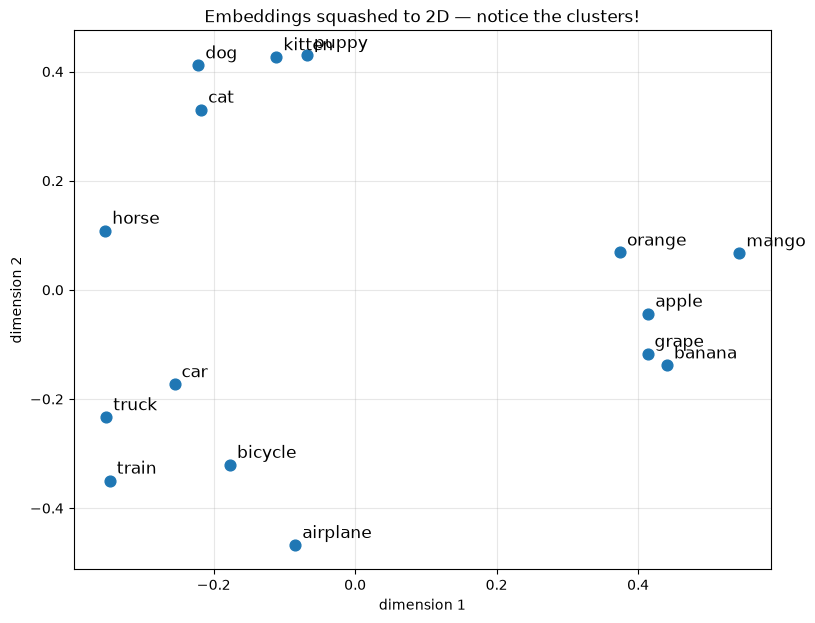

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = [
    # animals
    "cat", "dog", "kitten", "puppy", "horse",
    # fruit
    "apple", "banana", "orange", "grape", "mango",
    # vehicles
    "car", "truck", "bicycle", "airplane", "train",
]

word_vecs = embed(words)

# Squash 1536-D -> 2-D so we can plot it
coords = PCA(n_components=2).fit_transform(word_vecs)

plt.figure(figsize=(9, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=60)
for (x, y), word in zip(coords, words):
    plt.annotate(word, (x, y), fontsize=12, xytext=(5, 5), textcoords="offset points")
plt.title("Embeddings squashed to 2D — notice the clusters!")
plt.xlabel("dimension 1")
plt.ylabel("dimension 2")
plt.grid(True, alpha=0.3)
plt.show()

You should see **three clusters** — animals, fruit, and vehicles — grouped in different regions of the plot, without us ever labeling them. The model organized them purely by meaning.

> ⚠️ **Note:** PCA throws away most of the information to fit into 2D, so the picture is only a rough sketch. Two words looking a bit close on this plot might actually be far apart in the full 1536-D space. The *clusters*, though, are usually real.

> ✏️ **Try it:** add your own words (e.g. some colors, or countries) to the `words` list and re-run. Do they form their own cluster?

## 4. Seeing it in 3D 🌐

Two dimensions is easy to draw, but squashing 1536 numbers down to just 2 throws away *a lot*. Keeping **three** dimensions preserves more of the structure — and rotating the cube makes the clusters pop.

Let's use a bigger word list with **five** categories so the groupings are unmistakable, and color each category differently.

In [21]:
# More examples, grouped into categories. The model never sees these labels —
# we only use them to pick colors so the clusters are easy to spot.
categories = {
    "animals":   ["cat", "dog", "kitten", "puppy", "horse", "elephant", "rabbit"],
    "fruit":     ["apple", "banana", "orange", "grape", "mango", "strawberry", "pineapple"],
    "vehicles":  ["car", "truck", "bicycle", "airplane", "train", "motorcycle", "boat"],
    "countries": ["France", "Japan", "Brazil", "Canada", "Egypt", "India", "Norway"],
    "emotions":  ["happy", "sad", "angry", "excited", "afraid", "calm", "jealous"],
}

# Flatten into parallel lists of words + their category
all_words = [w for group in categories.values() for w in group]
word_cats = [cat for cat, group in categories.items() for _ in group]

big_vecs = embed(all_words)
print(f"Embedded {len(all_words)} words across {len(categories)} categories.")

Embedded 35 words across 5 categories.


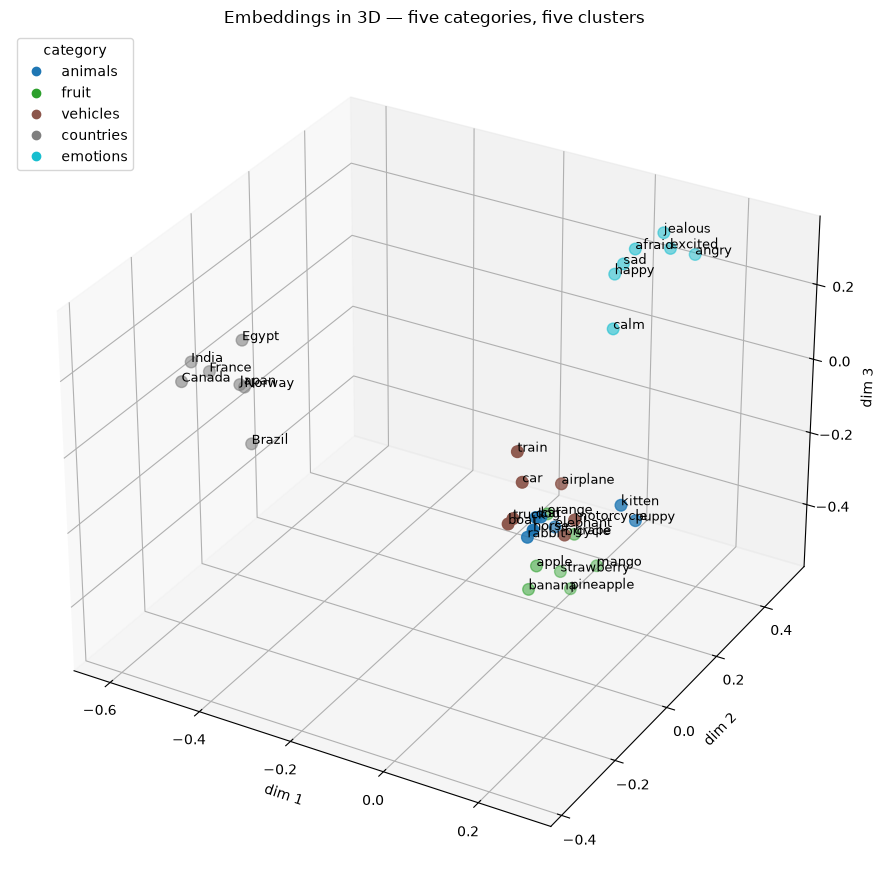

In [22]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the '3d' projection)

# Squash 1536-D -> 3-D
coords_3d = PCA(n_components=3).fit_transform(big_vecs)

# One color per category
cat_names = list(categories.keys())
palette = plt.cm.tab10(np.linspace(0, 1, len(cat_names)))
color_for = {name: palette[i] for i, name in enumerate(cat_names)}
colors = [color_for[c] for c in word_cats]

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2], c=colors, s=70, depthshade=True)

for (x, y, z), word in zip(coords_3d, all_words):
    ax.text(x, y, z, word, fontsize=9)

# A legend mapping color -> category
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=color_for[c], label=c) for c in cat_names]
ax.legend(handles=handles, title="category", loc="upper left")

ax.set_title("Embeddings in 3D — five categories, five clusters")
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
ax.set_zlabel("dim 3")
plt.tight_layout()
plt.show()

Each color forms its **own cloud** in space — animals near animals, countries near countries — all discovered purely from meaning.

> 🔄 **Make it rotatable!** A static image only shows one angle. To *spin* the matplotlib plot with your mouse, run this in a cell **before** the plot cell, then re-run the plot:
> ```python
> %matplotlib widget   # needs: pip install ipympl  (then restart the kernel)
> ```
> In classic Jupyter Notebook you can instead try `%matplotlib notebook`. Switch back with `%matplotlib inline` when done. (Or just use the Plotly version below — it's interactive out of the box.)

> 💡 **Why does 3D often look "better" than 2D?** With three axes, PCA keeps more of the original variation, so clusters that overlapped in 2D often separate cleanly. But we're *still* discarding 1533 dimensions — the true similarity always lives in the cosine score, not the picture.

> ✏️ **Try it:** add a sixth category (sports? colors? jobs?) to the `categories` dictionary above and re-run. Does it claim its own corner of the cube?

### Optional: a fully interactive 3D plot with Plotly

`matplotlib`'s 3D is fine, but **Plotly** gives you smooth drag-to-rotate, zoom, and hover-to-see-the-word right in the notebook. Run the install once if you'd like to try it.

In [23]:
%pip install -q plotly nbformat


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
# Optional — fully interactive 3D. Skip if you don't want the extra dependency.
# `nbformat` is what lets Plotly render inside the notebook (fixes the
# "Mime type rendering requires nbformat>=4.2.0" error).
%pip install -q plotly nbformat
import plotly.express as px

df_3d = pd.DataFrame(coords_3d, columns=["dim1", "dim2", "dim3"])
df_3d["word"] = all_words
df_3d["category"] = word_cats

fig = px.scatter_3d(
    df_3d, x="dim1", y="dim2", z="dim3",
    color="category", text="word",
    title="Embeddings in 3D (drag to rotate, scroll to zoom, hover for the word)",
)
fig.update_traces(marker=dict(size=6), textposition="top center")
fig.show()


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 5. Semantic search — the killer app

This is where embeddings shine in the real world (search engines, chatbots, recommendation systems, "chat with your documents").

**The idea:**
1. Embed a collection of documents *once* and store the vectors.
2. When a user asks a question, embed the *question*.
3. Return the documents whose vectors are **most similar** to the question's vector.

Unlike keyword search, this finds results by **meaning** — even when they share no words with the query.

In [10]:
# Our tiny "knowledge base"
documents = [
    "The Eiffel Tower is located in Paris, France.",
    "Photosynthesis lets plants convert sunlight into energy.",
    "The recipe calls for two cups of flour and one egg.",
    "Python is a popular programming language for beginners.",
    "The human heart pumps blood throughout the body.",
    "Mount Everest is the tallest mountain on Earth.",
]

# Step 1: embed all documents once
doc_vectors = embed(documents)


def search(query, top_k=3):
    """Return the top_k documents most similar in meaning to the query."""
    query_vec = embed(query)
    scores = [cosine_similarity(query_vec, dv) for dv in doc_vectors]
    ranked = sorted(zip(scores, documents), reverse=True)
    return ranked[:top_k]


query = "How do plants make food?"
print(f"Query: {query!r}\n")
for score, doc in search(query):
    print(f"  {score:.3f}  {doc}")

Query: 'How do plants make food?'

  0.533  Photosynthesis lets plants convert sunlight into energy.
  0.170  The human heart pumps blood throughout the body.
  0.115  The recipe calls for two cups of flour and one egg.


Notice the top hit is the **photosynthesis** sentence — even though the query says *"make food"* and the document says *"convert sunlight into energy"*. **Zero words in common, yet it wins**, because embeddings match on meaning, not spelling.

> ✏️ **Try it:** change the `query` to `"Where can I travel in Europe?"` or `"What language should I learn to code?"` and re-run. Does the right document rise to the top?

## 6. Your turn — exercise 🧑‍🎓

Put it all together. In the cell below:

1. Create your own list of **6–8 documents** about a topic you like (movies, sports, recipes...).
2. Embed them.
3. Write a `search()` query that has **no exact keyword overlap** with the answer you expect, and confirm semantic search still finds it.

Starter code is below — fill in the blanks.

In [ ]:
# 1. Your documents
my_docs = [
    # TODO: add 6-8 short sentences here
]

# 2. Embed them
# my_vectors = embed(my_docs)

# 3. Search (reuse the pattern from section 5)
# def my_search(query, top_k=3):
#     qv = embed(query)
#     scores = [cosine_similarity(qv, v) for v in my_vectors]
#     return sorted(zip(scores, my_docs), reverse=True)[:top_k]
#
# for score, doc in my_search("your question here"):
#     print(f"{score:.3f}  {doc}")

## Recap — what you learned

| Concept | In one sentence |
|---|---|
| **Embedding** | A list of numbers that captures the *meaning* of text. |
| **Dimension** | How many numbers are in the vector (1536 for `text-embedding-3-small`). |
| **Cosine similarity** | A score (−1 to 1) for how alike two vectors are; higher = more similar in meaning. |
| **Dimensionality reduction (PCA)** | Squashing high-D vectors down to 2D or 3D so we can *see* them. |
| **Semantic search** | Finding documents by meaning instead of exact keywords. |

### Where to go next
- Try the larger, more accurate model: change `MODEL` to `"text-embedding-3-large"`.
- Real apps store millions of vectors in a **vector database** (e.g. FAISS, Chroma, Pinecone) so search stays fast.
- Embeddings power **RAG** (Retrieval-Augmented Generation): fetch relevant text with embeddings, then feed it to a chat model to answer questions.

**Great work!** 🎉 You've gone from raw text to meaning-based math.